In [1]:
print("hello")

hello


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from textblob import TextBlob
from wordcloud import WordCloud

In [3]:
df = pd.read_csv("data4.csv")

In [5]:
df = pd.read_csv(
    "data4.csv",
    header=None,
    names=["ID", "Topic", "Sentiment", "Tweet"]
)

In [6]:
df.head()

,ID,Topic,Sentiment,Tweet
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 74682 entries, 0 to 74681
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   ID         74682 non-null  int64
 1   Topic      74682 non-null  str  
 2   Sentiment  74682 non-null  str  
 3   Tweet      73996 non-null  str  
dtypes: int64(1), str(3)
memory usage: 2.3 MB


In [8]:
df.shape

(74682, 4)

In [9]:
df.isnull().sum()

ID             0
Topic          0
Sentiment      0
Tweet        686
dtype: int64

In [11]:
df.dropna(inplace=True)

In [12]:
tweets = df["Tweet"]

In [13]:
def get_sentiment(text):
    analysis = TextBlob(str(text))

    polarity = analysis.sentiment.polarity

    if polarity > 0:
        return "Positive"

    elif polarity < 0:
        return "Negative"

    else:
        return "Neutral"

In [14]:
df["Predicted_Sentiment"] = df["Tweet"].apply(get_sentiment)

In [15]:
df.head()

,ID,Topic,Sentiment,Tweet,Predicted_Sentiment
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...,Neutral
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...,Neutral
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...,Neutral
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...,Neutral
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...,Neutral


In [16]:
sentiment_counts = df["Predicted_Sentiment"].value_counts()

print(sentiment_counts)

Predicted_Sentiment
Positive    34074
Negative    21358
Neutral     18564
Name: count, dtype: int64


C:\Users\itssa\AppData\Local\Temp\ipykernel_52560\1651215590.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


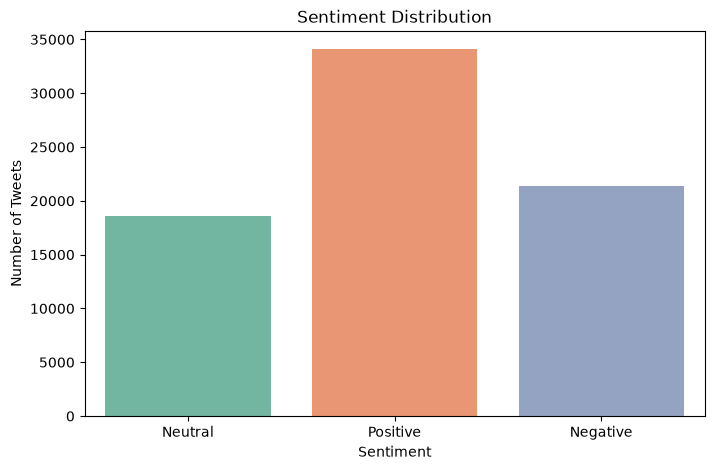

In [17]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="Predicted_Sentiment",
    data=df,
    palette="Set2"
)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Tweets")

plt.show()

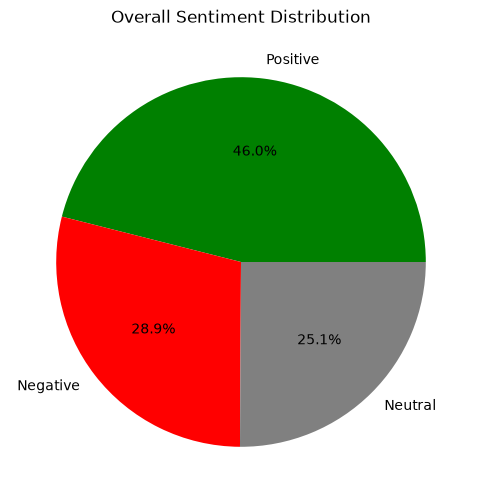

In [18]:
plt.figure(figsize=(6,6))

sentiment_counts.plot(
    kind="pie",
    autopct="%1.1f%%",
    colors=["green","red","gray"]
)

plt.ylabel("")

plt.title("Overall Sentiment Distribution")

plt.show()

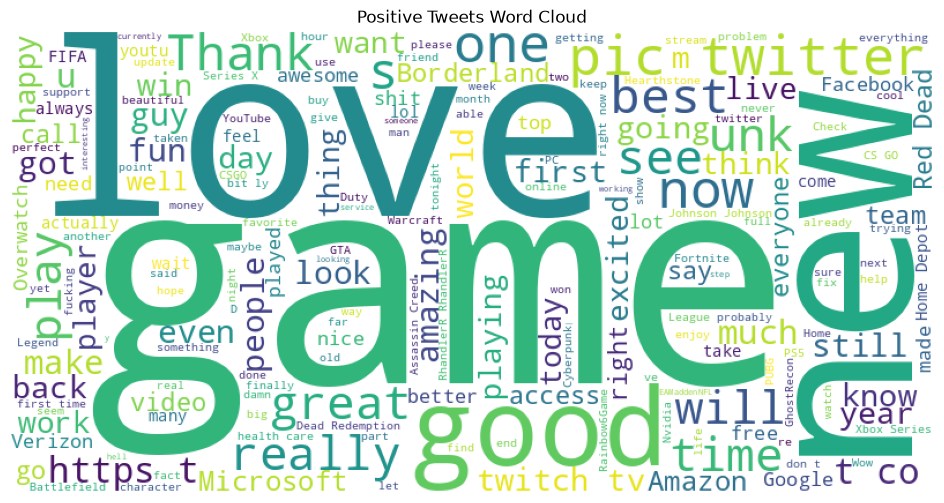

In [19]:
positive_text = " ".join(
    df[df["Predicted_Sentiment"]=="Positive"]["Tweet"]
)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(positive_text)

plt.figure(figsize=(12,6))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Positive Tweets Word Cloud")

plt.show()

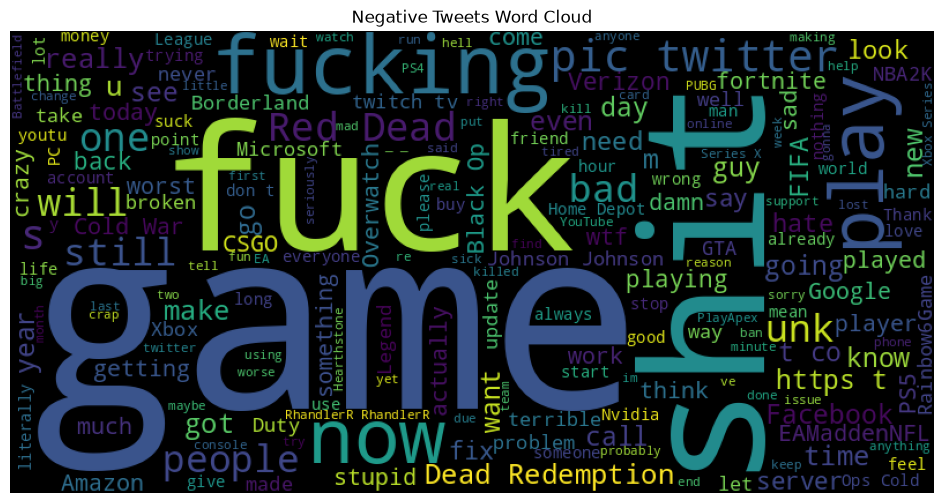

In [20]:
negative_text = " ".join(
    df[df["Predicted_Sentiment"]=="Negative"]["Tweet"]
)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="black"
).generate(negative_text)

plt.figure(figsize=(12,6))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Negative Tweets Word Cloud")

plt.show()

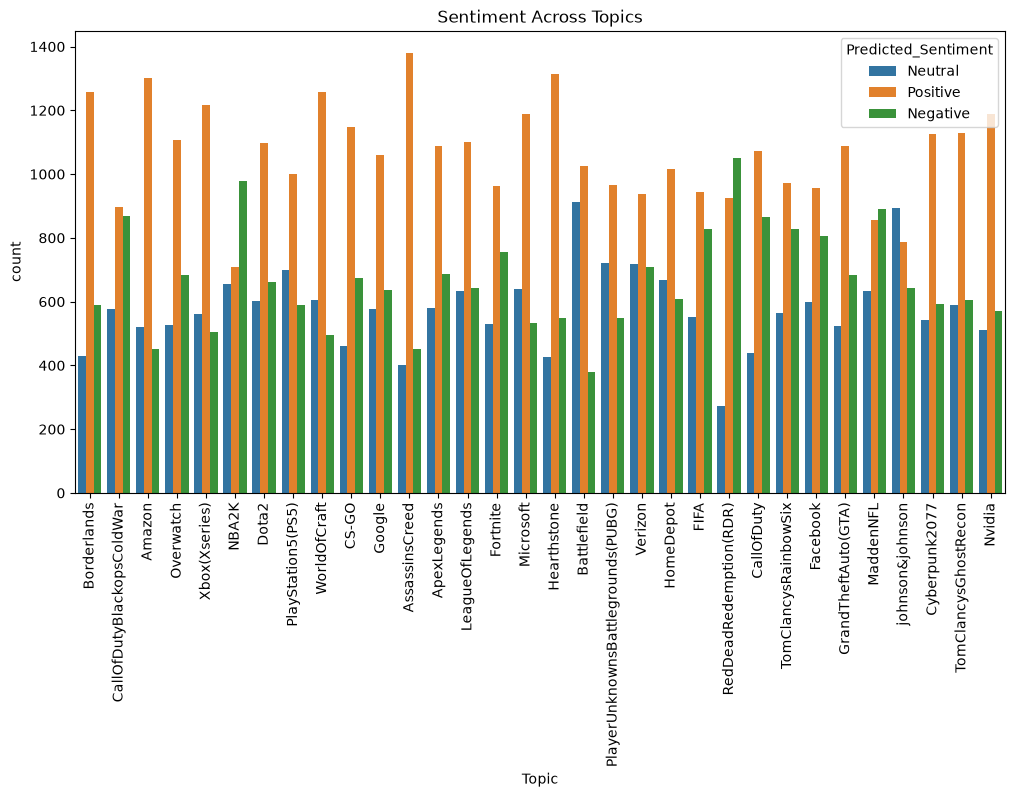

In [21]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    x="Topic",
    hue="Predicted_Sentiment"
)

plt.xticks(rotation=90)

plt.title("Sentiment Across Topics")

plt.show()

In [22]:
df.to_csv("Sentiment_Analysis_Result.csv", index=False)